# Инструменты аналитика: Jupyter, numpy, pandas, matplotlib

**Дисциплина «ИИ и машинное обучение»** · НИУ ВШЭ, Высшая школа бизнеса

Магистратура «Бизнес-аналитика и цифровые решения в финансах»

---

Этот ноутбук — вводная часть первого семинара, 30–40 минут. Он не учит
программированию: Python вы осваиваете в параллельном курсе. Задача здесь
другая — показать четыре инструмента, которыми пользуются на всех
последующих занятиях, и снять типовые затыки.

| Часть | Инструмент | Зачем он нужен |
|---|---|---|
| 1 | Jupyter | среда, где живёт весь код курса |
| 2 | numpy | быстрые вычисления над массивами чисел без циклов |
| 3 | pandas | таблицы: фильтры, группировки, новые столбцы |
| 4 | matplotlib | графики, без которых данные не понять |

**Как работать.** Ячейки с заголовком **Задание** содержат `...` или
`raise NotImplementedError` — их надо заменить своим кодом. Сразу под каждым
заданием стоит самопроверка: она печатает `✓ верно` либо подсказывает,
где ошибка.

---
# Часть 1. Как устроен ноутбук

Ноутбук — это последовательность **ячеек** двух видов:

* **ячейки кода** — их выполняет Python, результат появляется под ячейкой;
* **ячейки текста** (Markdown) — пояснения, как этот абзац.

Четыре вещи, которые надо знать сразу:

1. **Запуск ячейки — `Shift + Enter`.** Ячейка выполняется, курсор переходит
   к следующей. `Ctrl + Enter` выполняет, оставаясь на месте.
2. **Число в квадратных скобках слева** — порядковый номер выполнения.
   `[3]` значит «эта ячейка была выполнена третьей», а вовсе не «третья
   сверху». Пустые скобки `[ ]` — ячейка ещё не выполнялась.
3. **Переменные живут между ячейками.** Всё, что вы присвоили выше,
   доступно ниже — пока ядро не перезапущено.
4. **Порядок выполнения важнее порядка на экране.** Если что-то ведёт себя
   странно, жмите **«Перезапустить ядро и выполнить всё»** (Runtime → Restart
   and run all).

In [ ]:
2 + 2 * 10

Обратите внимание: результат появился, хотя никакого `print` не было.
Ноутбук сам показывает значение **последнего выражения** в ячейке.
Всё остальное надо печатать явно.

In [ ]:
print("эта строка напечатана явно")
5 * 5          # а это значение покажется само — оно последнее

### Задание 1.1
Заведите две переменные и посчитайте площадь прямоугольника.

In [ ]:
width = 12
height = 7

area = ...  # TODO: перемножьте width и height

print("Площадь:", area)
assert area == 84, "✗ должно получиться 84"
print("✓ верно")

## Что делать с ошибками

Ошибка в ноутбуке — это красный блок с трассировкой. **Читать его надо снизу
вверх:** последняя строка говорит, что именно случилось, а строка выше
показывает, где. Три самые частые ошибки на первых занятиях:

* `NameError: name 'x' is not defined` — переменной нет. Скорее всего, вы
  не выполнили ячейку выше, где она создаётся;
* `SyntaxError` — опечатка: пропущена скобка, кавычка или двоеточие;
* `KeyError: 'Название'` — обратились к столбцу таблицы, которого нет.
  Проверьте написание, регистр и пробелы.

Ниже ошибка вызвана намеренно и перехвачена, чтобы ноутбук не прервался.

In [ ]:
try:
    print(неизвестная_переменная)
except NameError as e:
    print("Поймали ошибку ->", type(e).__name__, ":", e)

## Где искать справку

* `Tab` после точки — список доступных методов: наберите `np.` и нажмите Tab;
* `Shift + Tab` внутри скобок функции — подсказка по её аргументам;
* `функция?` в отдельной ячейке — полная справка (например, `np.linspace?`);
* `help(функция)` — то же самое текстом.

Подключаем библиотеки

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.figsize": (7.2, 3.8), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED = "#0057b8", "#c0392b"


def check(ok, hint):
    "Самопроверка задания."
    if not ok:
        raise AssertionError("✗ " + hint)
    print("✓ верно")


print("numpy", np.__version__, "| pandas", pd.__version__)

Сокращения `np`, `pd` и `plt` — общепринятые. Пишите именно так: любой код
в интернете и в этом курсе рассчитан на них.

---
# Часть 2. numpy — вычисления без циклов

Обычный список Python не создан для математических операций: `[1, 2, 3] * 2` не удвоит числа,
а склеит список сам с собой. Массив numpy - это вектор из линейной алгебры

In [ ]:
plain = [1, 2, 3]
arr = np.array([1, 2, 3])

In [ ]:
print("список * 2 :", plain * 2)

In [ ]:
print("массив * 2 :", arr * 2)

In [ ]:
print("массив + 10:", arr + 10)

In [ ]:
print("массив ** 2:", arr ** 2)

In [ ]:
print("список ** 2:", plain ** 2)

Это называется **векторизацией**: операция применяется сразу ко всем
элементам. Циклы почти никогда не нужны — и это не только удобнее,
но и в десятки раз быстрее.

## Как создать массив

In [ ]:
print("из списка:      ", np.array([4, 8, 15, 16]))

In [ ]:
print("диапазон:       ", np.arange(0, 10, 2))        # от 0 до 10 с шагом 2

In [ ]:
print("равные отрезки: ", np.linspace(0, 1, 5))       # 5 точек от 0 до 1

In [ ]:
print("нули:           ", np.zeros(4))

In [ ]:
print("случайные:      ", np.random.default_rng(0).normal(size=4))

In [ ]:
table = np.array([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 10, 11, 12]])
print("\nтаблица:\n", table)
print("форма (строки, столбцы):", table.shape)
print("число измерений:", table.ndim)

### Задание 2.1
Создайте массив из чисел 1, 2, 3, ..., 9 и превратите его в матрицу 3х3,
в которой значения будут иметь исходный порядок. Пригодится `np.reshape`.

In [ ]:
values = ... # TODO: создайте массив из чисел 1-9
as_matrix = ...  # TODO: сделайте из него матрицу 3 × 3

print(values, "-> форма", values.shape)
print(as_matrix, "-> форма", as_matrix.shape)
check(values.shape == (9,) and as_matrix.shape == (3, 3),
      "нужен вектор из 9 чисел и матрица формы (3, 3)")

## Срезы и маски

Элементы берут по индексу (нумерация с нуля), диапазоны — срезом.
Один из важных приём — **булева маска**: сравнение даёт массив
из `True` и `False`, и по нему сразу отбираются нужные элементы.

In [ ]:
temps = np.array([12.5, 18.0, 7.3, 22.1, 15.6, 9.8, 25.4])

In [ ]:
print("первый:      ", temps[0])

In [ ]:
print("последний:   ", temps[-1])

In [ ]:
print("со 2 по 4:   ", temps[1:4])

In [ ]:
print("\nмаска temps > 15:", temps > 15)

In [ ]:
print("сами значения:  ", temps[temps > 15])

In [ ]:
print("сколько таких:  ", (temps > 15).sum())

Два приёма выше стоит запомнить:
`массив[маска]` отбирает элементы, а `маска.sum()` их считает — потому что
`True` при сложении ведёт себя как единица.

In [ ]:
temps = np.array([
    [12.5, 18.0, 7.3],
    [22.1, 15.6, 9.8],
    [25.4, 13.2, 3.6]
    ])

In [ ]:
print("срез по строкам 1-2:  \n", temps[:2])

In [ ]:
print("срез по столбцам 2-3:  \n", temps[:, 1:])

### Задание 2.2
Выберите из `temps` подматрицу 2х2 из правого нижнего угла

In [ ]:
matrix_2x2 = ...  # TODO: примените нужный срез к `temps`

print("Подматрица 2х2:\n", matrix_2x2)
check(np.all(matrix_2x2 == np.array([[15.6,  9.8], [13.2,  3.6]])),
      "где-то ошибка!")

### Задание 2.3
Отберите из `temps` значения ниже 3 градусов и больше 9 и посчитайте, сколько их.

In [ ]:
temps = np.array([-4.564, 15.987, -2.809,  2.217,  5.382, -2.755, -6.109,  4.557, 21.53 , 10.409])

days = ...  # TODO: примените маску temps < 13
n_days = ...  # TODO: посчитайте, сколько значений подошло

print("Холодные и не очень дни:", days, "— всего", n_days)
check(np.allclose(days, np.array([-4.564, 15.987, -2.809,  2.217, -2.755, -6.109, 21.53 , 10.409]), atol=1e-03) and n_days == 8,
      "где-то ошибка!")

## Агрегирующие функции и параметр axis

`sum`, `mean`, `std`, `min`, `max` без аргументов считают по всему массиву.
Для матрицы/таблицы важно указать, **вдоль чего** схлопывать, — это и есть `axis`.

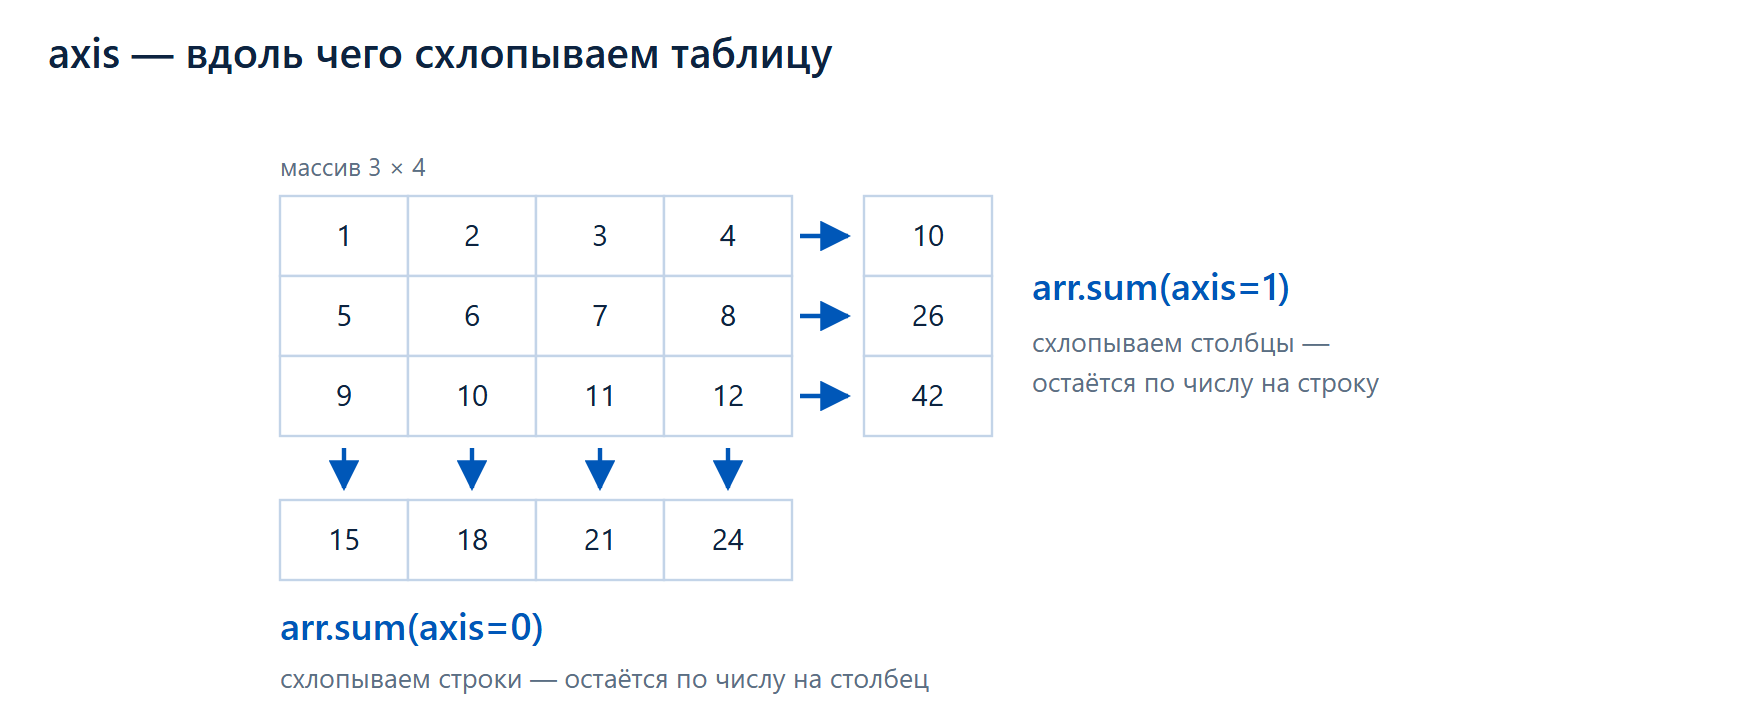

In [ ]:
table = np.array([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 10, 11, 12]])

In [ ]:
print("сумма всего:      ", table.sum())

In [ ]:
print("сумма по столбцам:", table.sum(axis=0))

In [ ]:
print("сумма по строкам: ", table.sum(axis=1))

In [ ]:
print("среднее по столбцам:", table.mean(axis=0))

### Задание 2.4
Посчитайте среднее и стандартное отклонение **каждого столбца** таблицы.

In [ ]:
col_mean = ...  # TODO: среднее каждого столбца
col_std = ...  # TODO: стандартное отклонение каждого столбца

print("средние:", col_mean)
print("разброс:", col_std)
check(col_mean.shape == (4,) and np.allclose(col_mean, [5, 6, 7, 8]),
      "должно получиться по одному числу на каждый из четырёх столбцов")

## Взвешенная сумма (скалярное, матричное произведение): оператор @

Последнее, что понадобится, — умножение. Звёздочка `*` умножает
поэлементно, а собачка `@` делает **скалярное произведение**: перемножает
попарно и складывает. Именно так считается прогноз любой линейной модели.

In [ ]:
counts = np.array([3, 2, 1, 4])
unit_g = np.array([400, 500, 2500, 60])

In [ ]:
print("поэлементно (*):", counts * unit_g)

In [ ]:
print("скалярно    (@):", counts @ unit_g)

In [ ]:
print("то же вручную:  ", (counts * unit_g).sum())

### Задание 2.5
Итоговая оценка за курс — взвешенная сумма баллов. Посчитайте её через `@`.

In [ ]:
weights = np.array([0.10, 0.20, 0.25, 0.15, 0.30])
scores = np.array([10, 7, 8, 6, 9])

grade = ...  # TODO: скалярное произведение весов и баллов

print("Итоговая оценка:", round(grade, 2))
check(abs(grade - 8.0) < 1e-9, "должно получиться ровно 8,0")

---
# Часть 3. pandas — таблицы

numpy удобен для чисел. Настоящие данные — таблица
с именованными столбцами разного смысла. Для неё есть `DataFrame`.

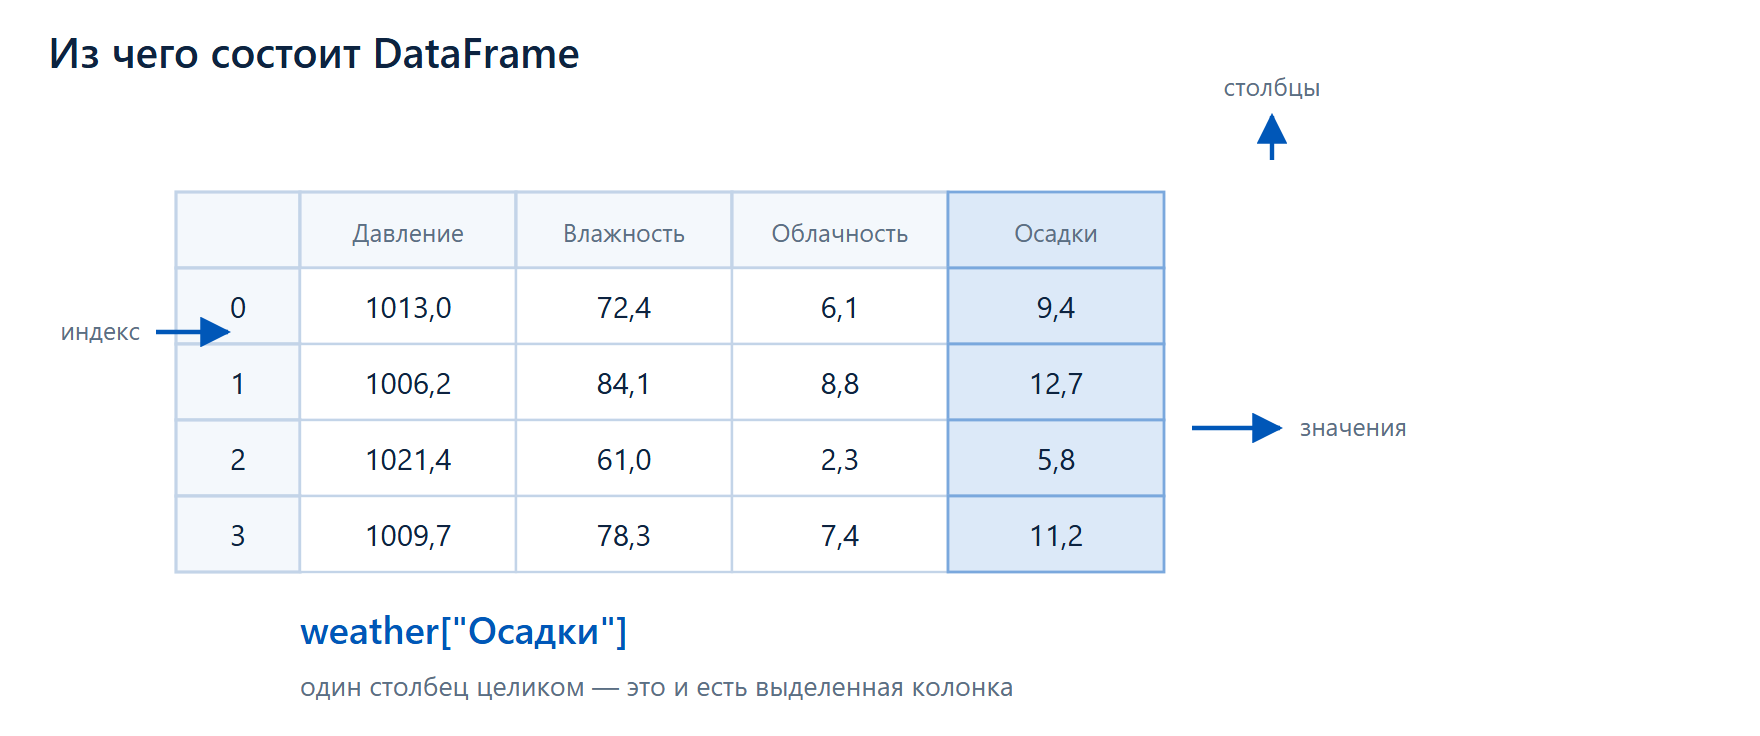

Три части, которые надо различать: **индекс** — метки строк, **столбцы** —
имена колонок, **значения** — сами числа и не только.

In [ ]:
small = pd.DataFrame({
    "Город": ["Москва", "Казань", "Сочи", "Пермь"],
    "Температура": [11.2, 9.8, 21.4, 6.3],
    "Осадки": [4.1, 6.7, 0.8, 12.5],
})
small

На курсе таблицы обычно читают из файла: `pd.read_csv("данные.csv")`.
Здесь мы соберём учебный архив погоды прямо в коде.

In [ ]:
# ── учебный архив погоды ───────────────────────────────────────────────────
# Архив синтетический: числа подобраны для наглядности. Веса W_TRUE заданы нами.
# В настоящей задаче их не знает никто.
rng = np.random.default_rng(20260908)
n_days = 365

pressure = np.round(760 + 8 * rng.normal(size=n_days), 1)
humidity = np.round(np.clip(70 + 12 * rng.normal(size=n_days), 25, 100), 1)
clouds = np.round(np.clip(5 + 2.5 * rng.normal(size=n_days), 0, 10), 1)
wind = np.round(np.clip(4 + 2 * rng.normal(size=n_days), 0, 15), 1)

FEATURES = ["Давление", "Влажность", "Облачность", "Ветер"]
RAW = np.column_stack([pressure, humidity, clouds, wind])
Z = (RAW - RAW.mean(axis=0)) / RAW.std(axis=0)
W_TRUE = np.array([-0.9, 1.2, 1.6, 0.35])
B_TRUE = 9.0
rainfall = np.round(B_TRUE + Z @ W_TRUE + 0.6 * rng.normal(size=n_days), 1)

weather = pd.DataFrame(RAW, columns=FEATURES)
weather["Осадки"] = rainfall

weather.head()

## Первый осмотр таблицы

Четыре команды pandas, с которых начинается работа с любыми данными.

In [ ]:
print("Размер таблицы:", weather.shape)

In [ ]:
print("\nТипы столбцов:")
print(weather.dtypes)

In [ ]:
print("\nПропуски по столбцам:")
print(weather.isna().sum())

In [ ]:
print("\nСтатистики по колонкам:")
weather.describe().round(1)

`describe()` — самая полезная из четырёх: сразу видно среднее, разброс,
минимум, максимум и квартили каждого столбца.

## Столбцы и фильтры

Один столбец берут по имени, несколько — списком имён.
Строки отбирают булевой маской — ровно как в numpy.

In [ ]:
print("Один столбец (первые 5):")
print(weather["Осадки"].head())

In [ ]:
print("\nНесколько столбцов:")
print(weather[["Облачность", "Осадки"]].head(3))

In [ ]:
rainy = weather[weather["Осадки"] > 11]
print("\nДней с сильным дождём:", len(rainy), "из", len(weather))

Условия объединяют через `&` (и), `|` (или), каждое — **в своих скобках**.
Привычные `and` / `or` здесь не работают, это частая ошибка.

### Задание 3.1
Выберите дни, когда облачность выше 7 баллов **и** давление ниже 755.

In [ ]:
mask = ...  # TODO: два условия, каждое в своих скобках, объединить через &
storm = ...  # TODO: примените маску к таблице

print("Подошло дней:", len(storm))
print("Средние осадки в них: %.1f мм против %.1f мм по всему архиву"
      % (storm["Осадки"].mean(), weather["Осадки"].mean()))
check(0 < len(storm) < len(weather), "маска не должна отбирать ни всё, ни ничего")
check(storm["Облачность"].min() > 7 and storm["Давление"].max() < 1010,
      "в отобранных строках должны выполняться оба условия сразу")

## Новые столбцы

Новый столбец создаётся присваиванием.
Заодно добавим дату: с ней таблица становится похожа на настоящую.

In [ ]:
weather["Дата"] = pd.date_range("2025-01-01", periods=len(weather))
weather["Месяц"] = weather["Дата"].dt.month
weather.head(3)

### Задание 3.2
Добавьте столбец `Сильный дождь` — `True`, если осадков больше 11 мм.

In [ ]:
...   #!SOLUTION: сравните столбец «Осадки» с порогом 11
weather

In [ ]:
print("Доля дней с сильным дождём: %.1f %%" % (100 * weather["Сильный дождь"].mean()))
check(weather["Сильный дождь"].dtype == bool, "столбец должен быть логическим: True или False")
check(0.10 < weather["Сильный дождь"].mean() < 0.30, "таких дней должно быть примерно пятая часть года")

## Группировка

`groupby` разбивает таблицу на группы по значению столбца и считает
что-нибудь внутри каждой. Это главный инструмент отчётности: «средний чек
по регионам», «доля отказов по возрастными группам», «осадки по месяцам».

In [ ]:
by_month = weather.groupby("Месяц")["Осадки"].mean().round(1)
print("Средние осадки по месяцам:")
print(by_month)

### Задание 3.3
Посчитайте для каждого месяца **долю дней с сильным дождём** и найдите
самый дождливый месяц.

In [ ]:
share_by_month = ...  # TODO: сгруппируйте по месяцу и возьмите среднее логического столбца
worst_month = ...  # TODO: месяц с наибольшей долей (idxmax)

print("Доля сильных дождей по месяцам:")
print((100 * share_by_month).round(0))
print("\nСамый дождливый месяц:", worst_month)
check(len(share_by_month) == 12, "групп должно получиться двенадцать — по числу месяцев")
check(share_by_month[worst_month] == share_by_month.max(), "worst_month должен указывать на максимум")

## Сортировка и выход в numpy

`sort_values` упорядочивает строки, `to_numpy()` отдаёт числа обратно
в numpy — так таблица превращается в матрицу признаков для модели.

### Задание 3.4
Найдите пять самых дождливых дней архива.

In [ ]:
top5 = ...  # TODO: отсортируйте по осадкам по убыванию и возьмите пять строк

print(top5[["Дата", "Облачность", "Давление", "Осадки"]].to_string(index=False))

X = weather[FEATURES].to_numpy()
print("\nМатрица признаков для модели:", X.shape, "— это уже обычный numpy")
check(len(top5) == 5 and top5["Осадки"].is_monotonic_decreasing,
      "нужно ровно пять строк, отсортированных по убыванию осадков")
check(top5["Осадки"].min() >= weather["Осадки"].nlargest(5).min(),
      "это должны быть самые дождливые дни, а не первые попавшиеся")

## Пропуски

В настоящих данных часть значений отсутствует — в таблице это `NaN`.
Их находят через `isna()`, а заполняют через `fillna()`.

In [ ]:
demo = weather.head(6)[["Давление", "Влажность", "Осадки"]].copy()
demo.loc[1, "Влажность"] = np.nan
demo.loc[4, "Давление"] = np.nan
demo

In [ ]:
print("Пропусков по столбцам:")
print(demo.isna().sum())
print("\nПосле заполнения медианой:")
print(demo.fillna(demo.median()).round(1))

---
# Часть 4. matplotlib — графики

Четыре типа графика достаточны почти для всех задач курса:

| Тип | Команда | Когда |
|---|---|---|
| Линия | `ax.plot(x, y)` | величина во времени |
| Точки | `ax.scatter(x, y)` | связь двух величин |
| Гистограмма | `ax.hist(x, bins=30)` | как распределена одна величина |
| Столбцы | `ax.bar(x, h)` | сравнение категорий |

Правильный способ рисовать — через пару «фигура и оси»:
`fig, ax = plt.subplots()`. Дальше все команды идут к `ax`.

In [ ]:
fig, ax = plt.subplots()
# plt.plot(weather["Дата"][:60], weather["Осадки"][:60], color=BLUE, lw=1.6)
# ax.set_xlabel("дата")
# ax.set_ylabel("осадки, мм")
# ax.set_title("Первые два месяца архива")
# plt.show()

Три команды `set_xlabel`, `set_ylabel`, `set_title` обязательны всегда.

Несколько графиков рядом получаются тем же `subplots` с указанием сетки.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].scatter(weather["Облачность"], weather["Осадки"], s=10, alpha=.5, color=BLUE)
axes[0].set_xlabel("облачность, баллы")
axes[0].set_ylabel("осадки, мм")
axes[0].set_title("Связь есть")

axes[1].scatter(weather["Ветер"], weather["Осадки"], s=10, alpha=.5, color=RED)
axes[1].set_xlabel("ветер, м/с")
axes[1].set_ylabel("осадки, мм")
axes[1].set_title("Связь слабая")

plt.tight_layout()
plt.show()

### Задание 4.1
Постройте гистограмму осадков: 30 интервалов, подписанные оси и заголовок.

In [ ]:
fig, ax = plt.subplots()

# TODO: ax.hist(...), затем set_xlabel, set_ylabel и set_title
raise NotImplementedError("замените эту строку своим решением")

plt.show()
check(len(ax.patches) == 30, "интервалов должно быть ровно 30 — параметр bins")
check(ax.get_xlabel() and ax.get_ylabel() and ax.get_title(),
      "подпишите обе оси и поставьте заголовок")

### Задание 4.2
Постройте столбчатую диаграмму средних осадков по месяцам. Данные для неё
вы уже посчитали в задании 3.3 — переменная `by_month`.

In [ ]:
fig, ax = plt.subplots()

# TODO: ax.bar(by_month.index, by_month.values), затем подписи осей и заголовок
raise NotImplementedError("замените эту строку своим решением")

plt.show()
check(len(ax.patches) == 12, "столбцов должно быть двенадцать — по числу месяцев")
check(ax.get_xlabel() and ax.get_ylabel() and ax.get_title(),
      "подпишите обе оси и поставьте заголовок")

---
# Шпаргалка

| Задача | Как |
|---|---|
| выполнить ячейку | `Shift + Enter` |
| всё сломалось | «Перезапустить ядро и выполнить всё» |
| подсказка по функции | `Shift + Tab` внутри скобок, либо `функция?` |
| массив из списка | `np.array([1, 2, 3])` |
| форма массива | `arr.shape` |
| отобрать по условию | `arr[arr > 5]` |
| посчитать подходящие | `(arr > 5).sum()` |
| среднее по столбцам | `arr.mean(axis=0)` |
| взвешенная сумма | `w @ x` |
| прочитать таблицу | `pd.read_csv("файл.csv")` |
| осмотреть таблицу | `df.shape`, `df.head()`, `df.describe()` |
| один столбец | `df["Имя"]` |
| фильтр строк | `df[(df["a"] > 1) & (df["b"] < 2)]` |
| новый столбец | `df["Новый"] = ...` |
| группировка | `df.groupby("Ключ")["Значение"].mean()` |
| сортировка | `df.sort_values("Столбец", ascending=False)` |
| пропуски | `df.isna().sum()`, `df.fillna(df.median())` |
| в numpy | `df[столбцы].to_numpy()` |
| график | `fig, ax = plt.subplots()`, затем `ax.plot(...)` |
| подписи | `ax.set_xlabel(...)`, `set_ylabel`, `set_title` |

# Что дальше

Инструменты есть. Теперь переходите ко второму ноутбуку — «Математика
машинного обучения». Там мы возьмём этот же архив погоды и по нему найдём
веса предсказательной модели: посчитаем ошибку, узнаем, в какую сторону её уменьшать, и
триста раз шагнём в эту сторону.